# tap.adsr~ — the envelope, measured

The rebuilt envelope kernel (`taptools/adsr.h`): the default `analog` mode is a circuit
model — an RC attack charging toward a 1.4× overshoot target and truncated at full scale
(the CEM 3310 architecture), with decay and release as true RC discharges that taper into
their targets — while the 2003 Jamoma curves survive verbatim as the `hybrid` / `linear` /
`exponential` compatibility modes. Every trace below drives the **shipping C++** through
`tools/capi` via ctypes.

Sections: **1** analog vs. the legacy curves · **2** the contract numbers ·
**3** gate amplitude is velocity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def gate_square(on_s, off_s, level=1.0):
    return np.concatenate([np.full(int(on_s * sr), level), np.zeros(int(off_s * sr))])

## 1 · The shape of the circuit

One gate, four modes: attack 100 ms, decay 300 ms, sustain −12 dB, release 400 ms. The
analog attack is convex — fast off the mark, easing into the peak, the truncated charge —
where the legacy hybrid/linear attacks are straight lines. And the analog decay *tapers
into* sustain asymptotically while the legacy curves hit it and stop dead: the difference
between a capacitor and a ramp.

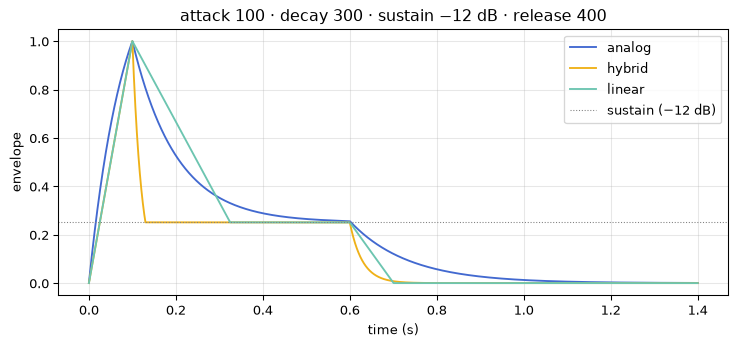

In [2]:
g = gate_square(0.6, 0.8)
t = np.arange(g.size) / sr

fig, ax = plt.subplots(figsize=(9, 3.6))
for mode, color in [("analog", C[0]), ("hybrid", C[1]), ("linear", C[3])]:
    env = tap.Adsr(sr, attack=100, decay=300, sustain=-12, release=400, mode=mode)
    ax.plot(t, env.process(g), color=color, lw=1.4, label=mode)
ax.axhline(10 ** (-12 / 20), color="gray", lw=0.8, ls=":", label="sustain (−12 dB)")
ax.set_xlabel("time (s)")
ax.set_ylabel("envelope")
ax.set_title("attack 100 · decay 300 · sustain −12 dB · release 400")
ax.legend(loc="upper right")
plt.show()

## 2 · The contract numbers

The header's promises, measured: the analog attack reaches full scale at exactly the knob
time with its midpoint at 1.4·(1 − e^(−ln 3.5 / 2)) ≈ 0.652; decay and release close 95 %
of their gap at their knob times (τ = t/3); and the release genuinely ends at zero (the
asymptote is truncated below 1e-6). The same numbers are pinned CI-side in
`tests/adsr_test.cpp`.

In [3]:
env = tap.Adsr(sr, attack=100, decay=200, sustain=-12, release=100)
y = env.process(gate_square(1.0, 1.0))

a = int(0.100 * sr)
first_peak = int(np.argmax(y >= 0.999))
print(f"attack: reaches full scale at {first_peak / sr * 1000:.1f} ms (knob: 100.0);"
      f" midpoint {y[a // 2]:.3f} (law: 0.652)")

sus = 10 ** (-12 / 20)
closed = 1 - (y[a + int(0.200 * sr)] - sus) / (1 - sus)
print(f"decay: {closed * 100:.1f} % of the gap closed at the 200 ms knob (contract: ≥95 %)")

rel_start = int(1.0 * sr)
rel = y[rel_start:]
print(f"release: level {rel[int(0.100 * sr)]:.4f} at the 100 ms knob;"
      f" final sample {rel[-1]} (exactly zero — the stage ends)")

attack: reaches full scale at 99.8 ms (knob: 100.0); midpoint 0.652 (law: 0.652)
decay: 95.0 % of the gap closed at the 200 ms knob (contract: ≥95 %)
release: level 0.0126 at the 100 ms knob; final sample 0.0 (exactly zero — the stage ends)


## 3 · Gate amplitude is velocity

The family contract lands: with `velocity` sensitivity at 1, a plain 1.0 gate is unity, an
accented 2.0 gate (the 303 convention) hits twice as hard, and a half-level gate lands
soft. At sensitivity 0 the envelope is amplitude-blind — the legacy behavior, still the
default. The default `threshold` (0.005) also hears the 808 sequencer's plain level
(0.01), retiring the old hard-coded 0.5 gate that a default accented row could never
open.

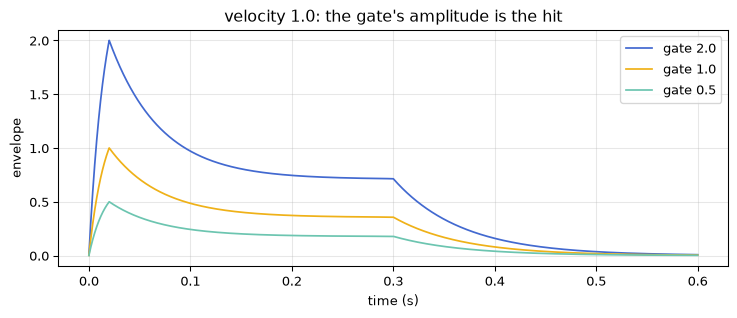

a plain 0.01 sequencer hit opens the envelope: level 0.819 after 20 ms


In [4]:
fig, ax = plt.subplots()
for amp, color in [(2.0, C[0]), (1.0, C[1]), (0.5, C[3])]:
    env = tap.Adsr(sr, attack=20, decay=150, sustain=-9, release=200, velocity=1.0)
    y = env.process(gate_square(0.3, 0.3, level=amp))
    ax.plot(np.arange(y.size) / sr, y, color=color, lw=1.3, label=f"gate {amp}")
ax.set_xlabel("time (s)")
ax.set_ylabel("envelope")
ax.set_title("velocity 1.0: the gate's amplitude is the hit")
ax.legend(loc="upper right")
plt.show()

env = tap.Adsr(sr, attack=5)
y = env.process(np.full(int(0.02 * sr), 0.01))  # the seq's plain level
print(f"a plain 0.01 sequencer hit opens the envelope: level {y[-1]:.3f} after 20 ms")

---

Every number above is the shipping kernel through its C ABI; the same contract points are
pinned in `tests/adsr_test.cpp`, alongside the scenario that keeps the legacy hybrid curve
honest (linear attack midpoint 0.5, dB-linear decay). The wrapper's default mode is now
`analog`; the Jamoma curves remain one attribute away.